# SAR Satellites & Frequency Bands: An InSAR Primer

**Welcome!** In this notebook we explore how different SAR (Synthetic Aperture Radar) satellites
observe earthquake-induced ground deformation, and why the choice of frequency band matters.

By the end you will understand:
1. What frequency bands (X / C / S / L) exist and how they differ
2. Which satellites operate in each band
3. How wavelength affects fringe density, sensitivity, and coherence
4. Trade-offs between resolution, revisit time, and cost
5. How viewing geometry (ascending vs. descending) changes the picture

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib import cm
import sys, os

# Make eq_insar importable if running from the examples/ folder
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

from eq_insar import (
    generate_synthetic_insar,
    SATELLITES,
    get_satellite,
    list_satellites,
    compute_los_vector,
    displacement_to_phase,
    wrap_phase,
)

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Reproducibility
SEED = 42

print('Ready!')

Ready!


## 1. Meet the Satellites

Let's start by listing every SAR satellite available in our library and
organising them by frequency band.

In [2]:
# Collect satellite info into a handy list
sats = list_satellites()

band_colors = {'X': '#e74c3c', 'C': '#2ecc71', 'S': '#f39c12', 'L': '#3498db'}
band_order  = ['X', 'C', 'S', 'L']

print(f"{'Satellite':<18} {'Band':>4}  {'Wavelength':>12}  {'Revisit':>8}  {'Resolution':>11}  {'Agency'}")
print('-' * 80)
for key in sorted(sats, key=lambda k: (band_order.index(sats[k].band), sats[k].name)):
    s = sats[key]
    print(f"{s.name:<18} {s.band:>4}  {s.wavelength_m*100:>9.2f} cm   {s.revisit_days:>5d} d   {s.resolution_m:>8.1f} m   {s.agency}")

Satellite          Band    Wavelength   Revisit   Resolution  Agency
--------------------------------------------------------------------------------
COSMO-SkyMed          X       3.12 cm       1 d        1.0 m   ASI
ICEYE                 X       3.11 cm       1 d        1.0 m   ICEYE
TerraSAR-X            X       3.11 cm      11 d        1.0 m   DLR
ENVISAT               C       5.62 cm      35 d       30.0 m   ESA
RADARSAT-2            C       5.55 cm      24 d        3.0 m   CSA
Sentinel-1            C       5.55 cm       6 d        5.0 m   ESA
ALOS-2                L      22.91 cm      14 d        3.0 m   JAXA
NISAR                 L      23.80 cm      12 d        7.0 m   NASA/ISRO
SAOCOM                L      23.50 cm      16 d       10.0 m   CONAE


### 1.1 Wavelength Landscape

The plot below shows each satellite positioned by its radar wavelength.
Longer wavelength = better vegetation penetration but coarser phase sensitivity.

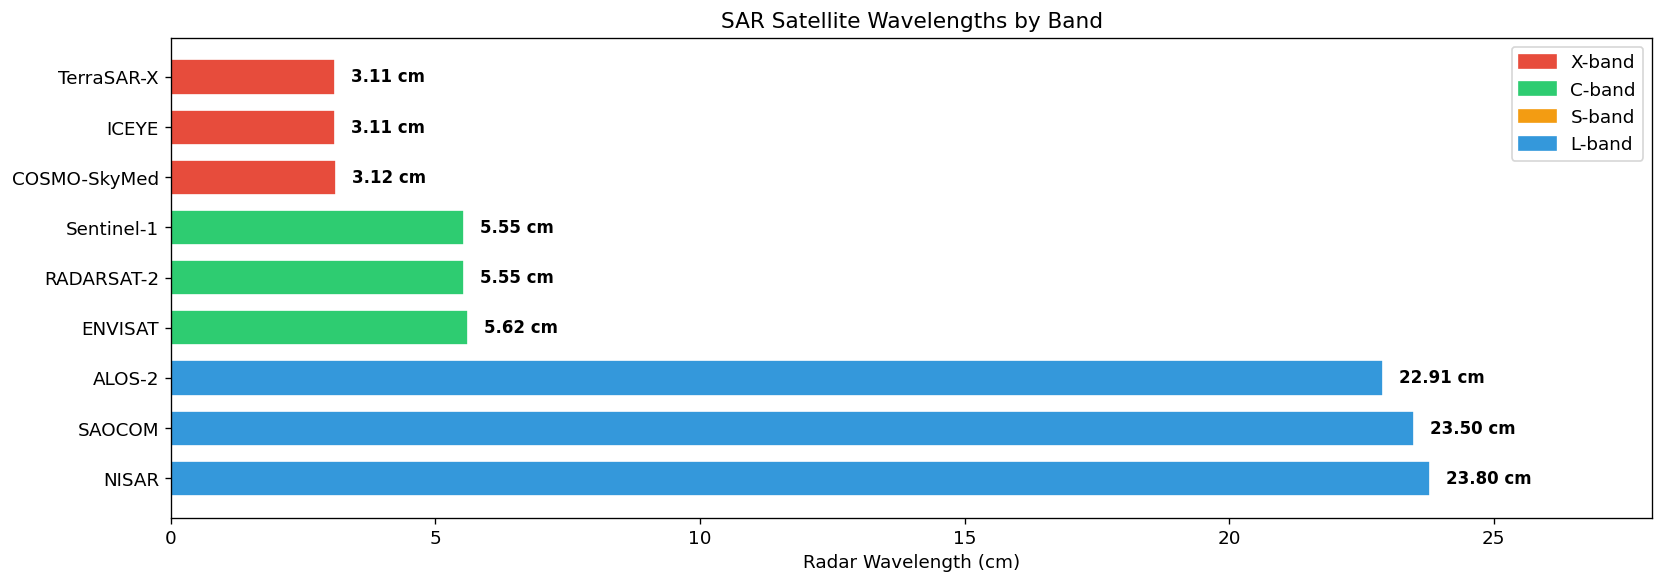

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))

for i, key in enumerate(sorted(sats, key=lambda k: sats[k].wavelength_m)):
    s = sats[key]
    color = band_colors[s.band]
    ax.barh(i, s.wavelength_m * 100, color=color, edgecolor='white', height=0.7)
    ax.text(s.wavelength_m * 100 + 0.3, i, f"{s.wavelength_m*100:.2f} cm",
            va='center', fontsize=10, fontweight='bold')

names = [sats[k].name for k in sorted(sats, key=lambda k: sats[k].wavelength_m)]
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Radar Wavelength (cm)')
ax.set_title('SAR Satellite Wavelengths by Band')
ax.set_xlim(0, 28)

# Band legend
handles = [mpatches.Patch(color=band_colors[b], label=f'{b}-band') for b in band_order]
ax.legend(handles=handles, loc='best', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()